# LFW Evaluation Report

10-fold cross-validated face verification on LFW (full 6000 pairs, strict mode with raw fallback for missing alignments).

Re-execute this notebook end-to-end after a training run. It loads `application/models/best.pt` and writes figures to `evaluation/figs/`.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
from PIL import Image
from torch.utils.data import DataLoader, Dataset

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'process-data'))

from lfw_layout import find_lfw_identity_root
from training_pipeline.src.eval_lfw import load_pairs_txt, _load_image_with_fallback, _pair_paths
from training_pipeline.src.model import FaceEmbedding

FIGS = ROOT / 'evaluation/figs'
FIGS.mkdir(parents=True, exist_ok=True)

metrics = json.loads((ROOT / 'evaluation/results.json').read_text())
print(json.dumps(metrics, indent=2))

{
  "mean_acc": 0.909,
  "std_acc": 0.010883218478209677,
  "threshold_global": 0.565,
  "n_pairs": 6000,
  "n_pairs_total": 6000,
  "n_pairs_used": 6000,
  "n_unique_images": 7701,
  "n_aligned": 3581,
  "n_raw_fallback": 4120,
  "pos_sim_mean": 0.7636424723189945,
  "pos_sim_std": 0.16660678376053217,
  "neg_sim_mean": 0.1790994448744847,
  "neg_sim_std": 0.26470119856118657,
  "spread": 0.5845430274445098,
  "pos_ratio": 0.5
}


In [2]:
# Load model + embed every unique image referenced by the LFW pairs.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
ckpt = torch.load(ROOT / 'application/models/best.pt', map_location=device, weights_only=False)
model = FaceEmbedding(embedding_dim=ckpt['cfg']['train']['embedding_dim'], pretrained=False).to(device).eval()
model.load_state_dict(ckpt['model'])

pairs = load_pairs_txt(ROOT / 'preprocess-data/lfw/pairs.txt')
aligned_root = ROOT / 'process-data/lfw_pairs'
raw_root = find_lfw_identity_root(ROOT / 'preprocess-data/lfw')

# Unique (aligned, raw) tuples, indexed by (name, idx) key.
by_key = {}
unique = []
for p in pairs:
    (a1, r1), (a2, r2) = _pair_paths(p, aligned_root, raw_root)
    for key, paths in [((p.name1, p.idx1), (a1, r1)), ((p.name2, p.idx2), (a2, r2))]:
        if key not in by_key:
            by_key[key] = len(unique)
            unique.append(paths)

class _D(Dataset):
    def __init__(self, items): self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        t, _ = _load_image_with_fallback(*self.items[i])
        return t

with torch.no_grad():
    embs = torch.cat([
        model.embed_normalized(b.to(device)).cpu()
        for b in DataLoader(_D(unique), batch_size=128, num_workers=0)
    ])

sims = np.array([
    float((embs[by_key[(p.name1, p.idx1)]] * embs[by_key[(p.name2, p.idx2)]]).sum())
    for p in pairs
])
labels = np.array([p.same for p in pairs])
print(f'Embedded {len(unique)} unique images for {len(pairs)} pairs')

Embedded 7701 unique images for 6000 pairs


## Sample triplet visualization

Anchor + Positive: same person. Negative: random different person.

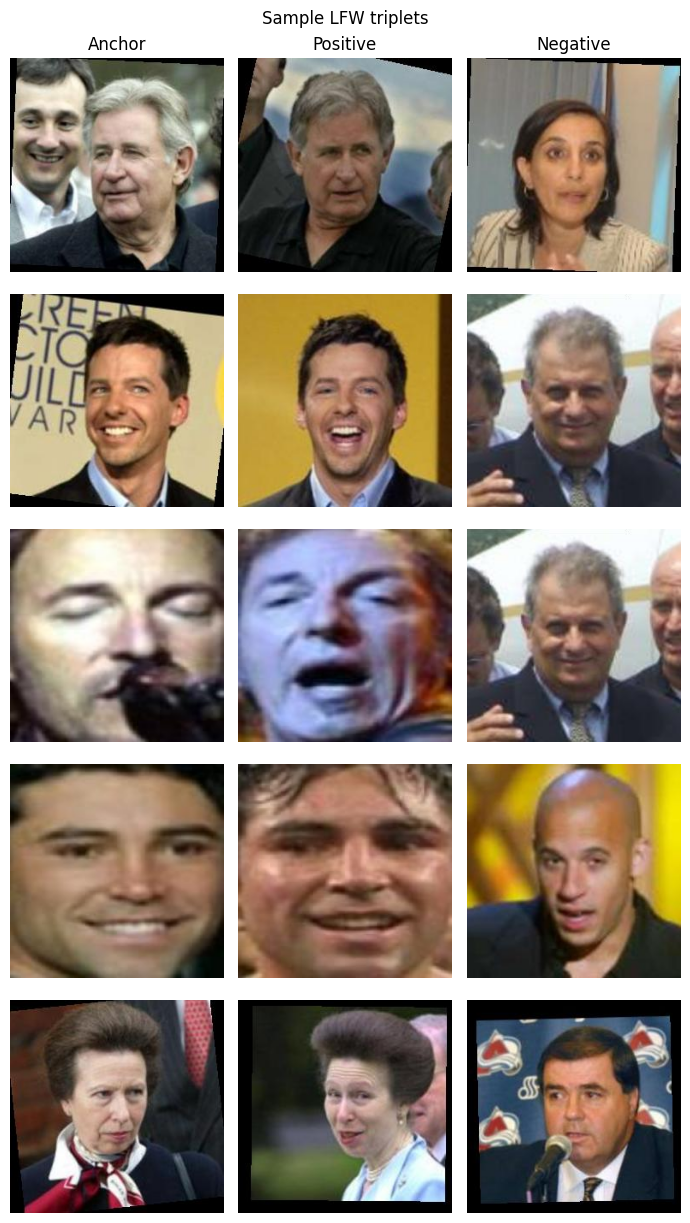

In [3]:
import random
rng = random.Random(0)
pos_pairs = [p for p in pairs if p.same == 1]
neg_pairs = [p for p in pairs if p.same == 0]
rng.shuffle(pos_pairs); rng.shuffle(neg_pairs)

def _open(name, idx):
    aligned = aligned_root / name / f'{name}_{idx:04d}.jpg'
    raw = raw_root / name / f'{name}_{idx:04d}.jpg'
    return Image.open(aligned if aligned.exists() else raw).convert('RGB')

n_rows = 5
fig, axes = plt.subplots(n_rows, 3, figsize=(7, 2.5 * n_rows))
for row in range(n_rows):
    p_pos, p_neg = pos_pairs[row], neg_pairs[row]
    axes[row, 0].imshow(_open(p_pos.name1, p_pos.idx1)); axes[row, 0].axis('off')
    axes[row, 1].imshow(_open(p_pos.name2, p_pos.idx2)); axes[row, 1].axis('off')
    axes[row, 2].imshow(_open(p_neg.name2, p_neg.idx2)); axes[row, 2].axis('off')
    if row == 0:
        axes[row, 0].set_title('Anchor')
        axes[row, 1].set_title('Positive')
        axes[row, 2].set_title('Negative')
fig.suptitle('Sample LFW triplets')
plt.tight_layout()
plt.savefig(FIGS / 'triplets.png', dpi=150)
plt.show()

## Sample pair similarity

One concrete positive and negative pair with their cosine similarity scores.

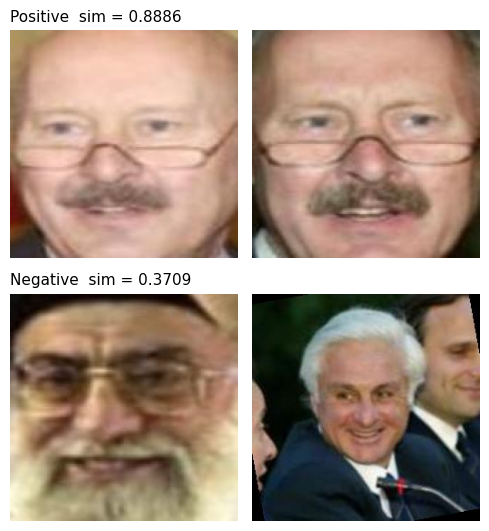

Positive similarity: 0.8886
Negative similarity: 0.3709


In [4]:
rng = random.Random(7)
pos_idx = rng.choice([i for i, l in enumerate(labels) if l == 1])
neg_idx = rng.choice([i for i, l in enumerate(labels) if l == 0])
pp, pn = pairs[pos_idx], pairs[neg_idx]

fig, axes = plt.subplots(2, 2, figsize=(5, 5.5))
axes[0, 0].imshow(_open(pp.name1, pp.idx1)); axes[0, 0].axis('off')
axes[0, 1].imshow(_open(pp.name2, pp.idx2)); axes[0, 1].axis('off')
axes[1, 0].imshow(_open(pn.name1, pn.idx1)); axes[1, 0].axis('off')
axes[1, 1].imshow(_open(pn.name2, pn.idx2)); axes[1, 1].axis('off')
axes[0, 0].set_title(f'Positive  sim = {sims[pos_idx]:.4f}', loc='left', fontsize=11)
axes[1, 0].set_title(f'Negative  sim = {sims[neg_idx]:.4f}', loc='left', fontsize=11)
plt.tight_layout(); plt.savefig(FIGS / 'sample_pair.png', dpi=150); plt.show()
print(f'Positive similarity: {sims[pos_idx]:.4f}')
print(f'Negative similarity: {sims[neg_idx]:.4f}')

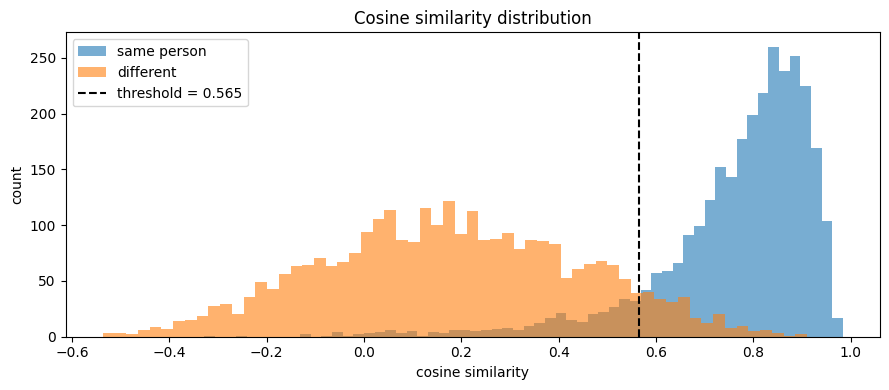

In [5]:
# Similarity distribution.
plt.figure(figsize=(9, 4))
plt.hist(sims[labels == 1], bins=60, alpha=0.6, label='same person')
plt.hist(sims[labels == 0], bins=60, alpha=0.6, label='different')
plt.axvline(metrics['threshold_global'], ls='--', c='k',
            label=f'threshold = {metrics["threshold_global"]:.3f}')
plt.legend(); plt.title('Cosine similarity distribution')
plt.xlabel('cosine similarity'); plt.ylabel('count')
plt.tight_layout(); plt.savefig(FIGS / 'sim_distribution.png', dpi=150); plt.show()

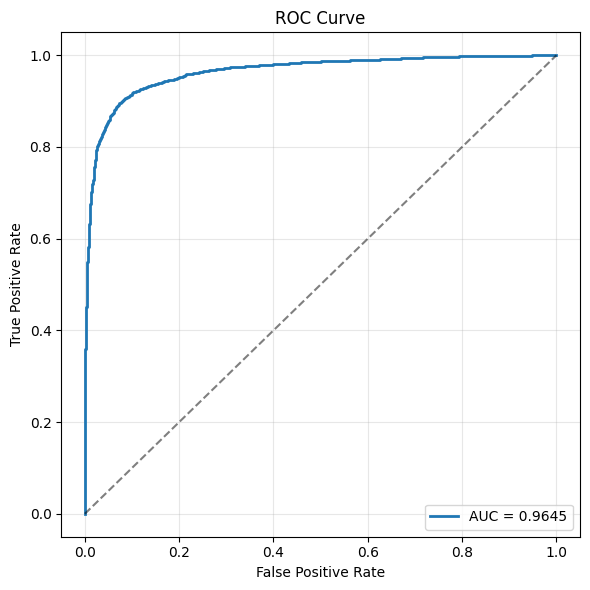

TPR @ FPR=1%: 0.6310 (threshold 0.7614)


In [6]:
# ROC + AUC.
fpr, tpr, thr = roc_curve(labels, sims)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(loc='lower right')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(FIGS / 'roc.png', dpi=150); plt.show()

idx = np.argmin(np.abs(fpr - 0.01))
print(f'TPR @ FPR=1%: {tpr[idx]:.4f} (threshold {thr[idx]:.4f})')

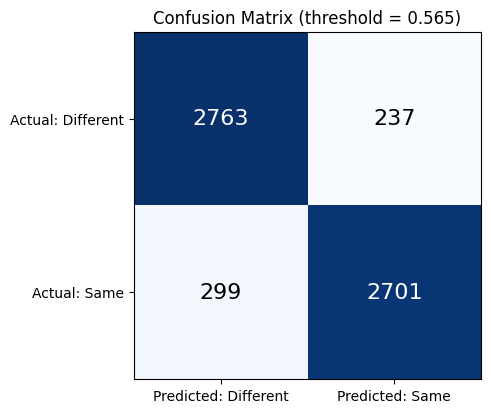

Accuracy:  0.9107
Precision: 0.9193
Recall:    0.9003
F1:        0.9097
TP=2701  FP=237  TN=2763  FN=299


In [7]:
# Confusion matrix at the chosen threshold.
t = metrics['threshold_global']
preds = (sims > t).astype(int)
cm = confusion_matrix(labels, preds)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Different', 'Predicted: Same'])
ax.set_yticklabels(['Actual: Different', 'Actual: Same'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=16)
ax.set_title(f'Confusion Matrix (threshold = {t:.3f})')
plt.tight_layout(); plt.savefig(FIGS / 'confusion_matrix.png', dpi=150); plt.show()

precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
print(f'Accuracy:  {(tp + tn) / cm.sum():.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1:        {f1:.4f}')
print(f'TP={tp}  FP={fp}  TN={tn}  FN={fn}')

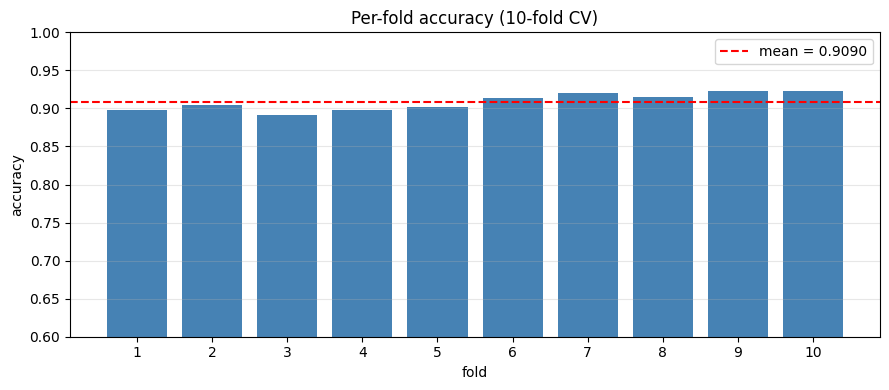

In [8]:
# Per-fold accuracy bar chart.
n = len(sims); n_folds = 10
fold_size = n // n_folds
cand = np.linspace(-1, 1, 401)
fold_acc = []
for f in range(n_folds):
    lo = f * fold_size
    hi = (f + 1) * fold_size if f < n_folds - 1 else n
    val = np.zeros(n, dtype=bool); val[lo:hi] = True
    train = ~val
    best_t, best_a = 0.0, 0.0
    for c in cand:
        a = ((sims[train] > c).astype(int) == labels[train]).mean()
        if a > best_a:
            best_t, best_a = c, a
    fold_acc.append(((sims[val] > best_t).astype(int) == labels[val]).mean())

plt.figure(figsize=(9, 4))
plt.bar(range(1, 11), fold_acc, color='steelblue')
plt.axhline(np.mean(fold_acc), color='red', ls='--', label=f'mean = {np.mean(fold_acc):.4f}')
plt.xticks(range(1, 11)); plt.ylim(0.6, 1.0)
plt.xlabel('fold'); plt.ylabel('accuracy')
plt.title('Per-fold accuracy (10-fold CV)')
plt.legend(); plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(FIGS / 'per_fold_accuracy.png', dpi=150); plt.show()

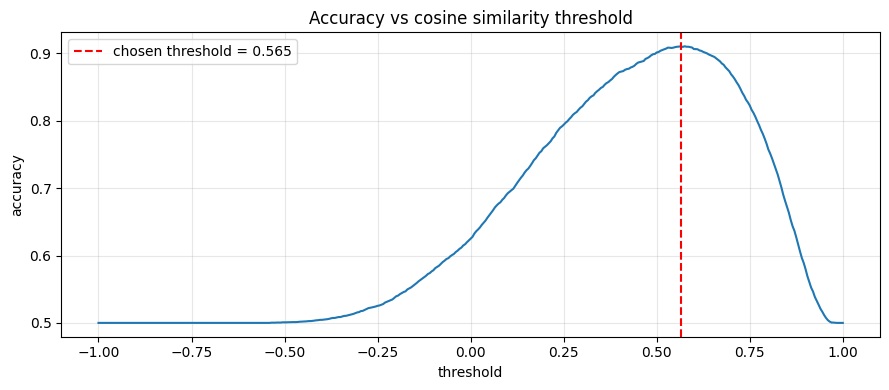

In [9]:
# Threshold sweep curve.
accs = [((sims > c).astype(int) == labels).mean() for c in cand]
plt.figure(figsize=(9, 4))
plt.plot(cand, accs)
plt.axvline(t, ls='--', c='red', label=f'chosen threshold = {t:.3f}')
plt.xlabel('threshold'); plt.ylabel('accuracy')
plt.title('Accuracy vs cosine similarity threshold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(FIGS / 'threshold_sweep.png', dpi=150); plt.show()

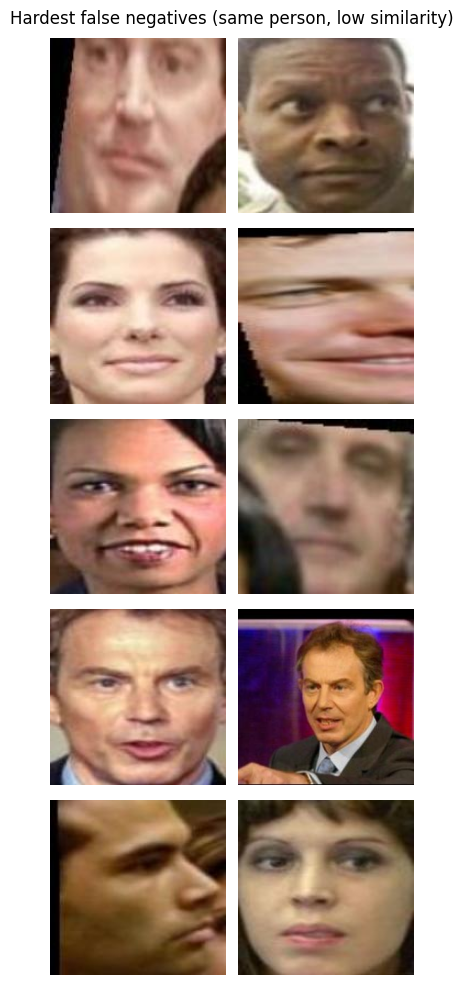

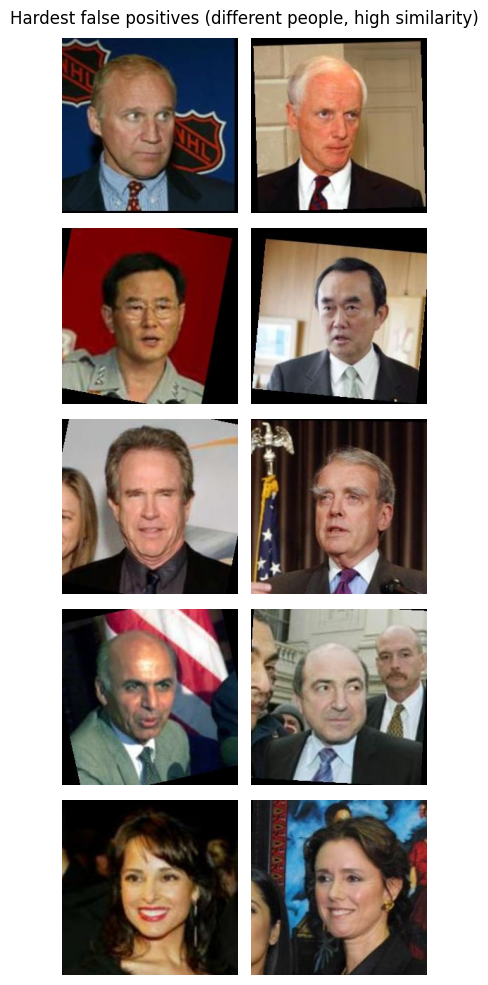

In [10]:
# Hardest false positives + false negatives.
order = np.argsort(sims)
fn_pairs = [pairs[i] for i in order if labels[i] == 1][:5]
fp_pairs = [pairs[i] for i in order[::-1] if labels[i] == 0][:5]

def grid(pair_list, title, fname):
    fig, axes = plt.subplots(len(pair_list), 2, figsize=(4, len(pair_list) * 2))
    if len(pair_list) == 1:
        axes = axes.reshape(1, -1)
    for i, p in enumerate(pair_list):
        axes[i, 0].imshow(_open(p.name1, p.idx1)); axes[i, 0].axis('off')
        axes[i, 1].imshow(_open(p.name2, p.idx2)); axes[i, 1].axis('off')
    fig.suptitle(title)
    plt.tight_layout(); plt.savefig(FIGS / fname, dpi=150); plt.show()

grid(fn_pairs, 'Hardest false negatives (same person, low similarity)', 'hardest_fn.png')
grid(fp_pairs, 'Hardest false positives (different people, high similarity)', 'hardest_fp.png')

In [11]:
# Summary table.
import pandas as pd
summary = {
    'Mean accuracy (10-fold)': f"{metrics['mean_acc']:.4f} \u00b1 {metrics['std_acc']:.4f}",
    'ROC AUC': f'{roc_auc:.4f}',
    'Chosen threshold': f"{t:.4f}",
    'TPR @ FPR=1%': f'{tpr[idx]:.4f}',
    'Precision': f'{precision:.4f}',
    'Recall': f'{recall:.4f}',
    'F1': f'{f1:.4f}',
    'pos_sim_mean': f"{metrics['pos_sim_mean']:.4f}",
    'neg_sim_mean': f"{metrics['neg_sim_mean']:.4f}",
    'spread (pos - neg)': f"{metrics['spread']:.4f}",
    'Total pairs': str(metrics['n_pairs']),
    'Aligned / fallback': f"{metrics['n_aligned']} / {metrics['n_raw_fallback']}",
}
pd.DataFrame(summary.items(), columns=['metric', 'value'])

,metric,value
0,Mean accuracy (10-fold),0.9090 ± 0.0109
1,ROC AUC,0.9645
2,Chosen threshold,0.5650
3,TPR @ FPR=1%,0.6310
4,Precision,0.9193
5,Recall,0.9003
6,F1,0.9097
7,pos_sim_mean,0.7636
8,neg_sim_mean,0.1791
9,spread (pos - neg),0.5845
